Epoch     0, loss 16.742
Epoch     1, loss 9.258
Epoch     2, loss 8.651
Epoch     3, loss 8.398
Epoch     4, loss 8.210
Epoch     5, loss 7.731
Epoch     6, loss 7.309
Epoch     7, loss 6.942
Epoch     8, loss 6.794
Epoch     9, loss 6.736
Epoch    10, loss 6.287
Epoch    11, loss 5.973
Epoch    12, loss 5.628
Epoch    13, loss 5.396
Epoch    14, loss 5.279
Epoch    15, loss 5.090
Epoch    16, loss 4.890
Epoch    17, loss 4.892
Epoch    18, loss 4.777
Epoch    19, loss 4.672
Epoch    20, loss 4.508
Epoch    21, loss 4.385
Epoch    22, loss 4.324
Epoch    23, loss 4.263
Epoch    24, loss 4.214
Epoch    25, loss 4.165
Epoch    26, loss 4.148
Epoch    27, loss 4.156
Epoch    28, loss 4.098
Epoch    29, loss 4.063
Epoch    30, loss 4.016
Epoch    31, loss 4.003
Epoch    32, loss 3.986
Epoch    33, loss 3.982
Epoch    34, loss 3.972
Epoch    35, loss 3.944
Epoch    36, loss 3.934
Epoch    37, loss 3.925
Epoch    38, loss 3.914
Epoch    39, loss 3.896
Epoch    40, loss 3.878
Epoch    41, lo

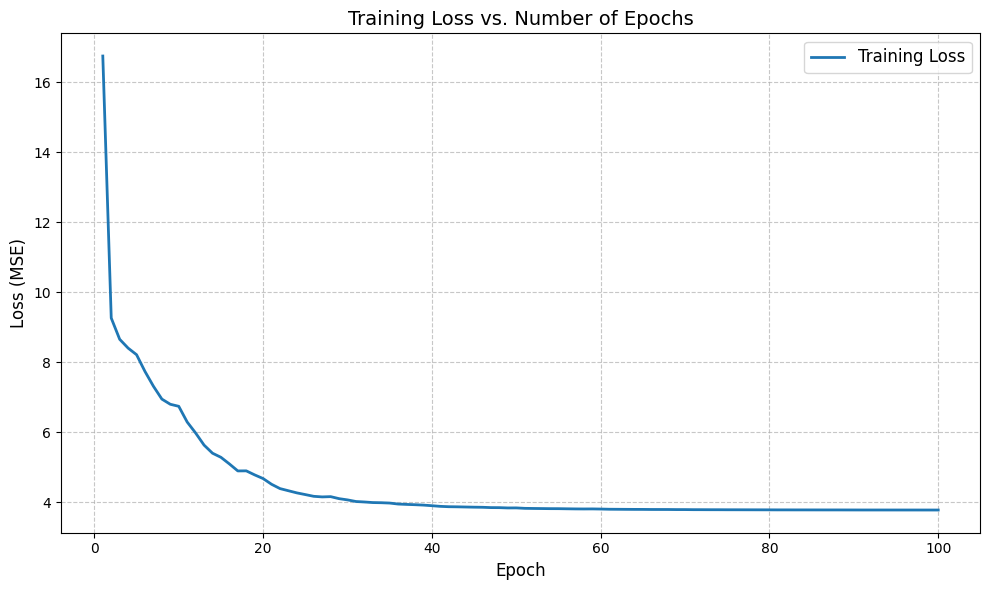

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt  # 新增：导入绘图库

# 定义输入维度、隐藏层维度、输出维度
D_i, D_k, D_o = 10, 40, 5

# 构建2层隐藏层的全连接网络
model = nn.Sequential(
    nn.Linear(D_i, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_o)
)

# He初始化（Kaiming正态初始化）
def weights_init(layer_in):
    if isinstance(layer_in, nn.Linear):
        nn.init.kaiming_normal_(layer_in.weight)
        layer_in.bias.data.fill_(0.0)

# 对模型应用初始化
model.apply(weights_init)

# 选择均方误差损失函数（回归任务）
criterion = nn.MSELoss()

# 构建SGD优化器，设置学习率和动量
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

# 学习率调度器：每10个epoch学习率减半
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

# 生成100个随机样本，封装为DataLoader
x = torch.randn(100, D_i)  # 输入数据：100个样本，每个样本10维
y = torch.randn(100, D_o)  # 标签数据：100个样本，每个标签5维
data_loader = DataLoader(TensorDataset(x, y), batch_size=10, shuffle=True)

loss_history = [] # 用于记录每个epoch的损失

# 训练循环：遍历数据集100次
for epoch in range(100):
    epoch_loss = 0.0
    # 遍历每个batch
    for i, data in enumerate(data_loader):
        x_batch, y_batch = data

        optimizer.zero_grad()

        pred = model(x_batch)
        loss = criterion(pred, y_batch)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() # 累计当前epoch的总损失

    loss_history.append(epoch_loss)
    print(f'Epoch {epoch:5d}, loss {epoch_loss:.3f}')
    scheduler.step()


plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), loss_history, label='Training Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training Loss vs. Number of Epochs', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()